<a href="https://colab.research.google.com/github/SofiiaBobr/goit_machine_learning/blob/main/tree/main/ML_2/ML_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Множини, Логіка, Комбінаторика та Графи


## Задача 1. Аналітика музичного сервісу
**Умова**
Ви працюєте аналітиком у музичному стрімінговому сервісі. У вас є дані про вподобання користувачів за останній місяць у вигляді ID клієнтів. Маркетинговий відділ хоче зрозуміти перетин аудиторій для планування рекламних кампаній.

Дано три множини користувачів:
* `rock_fans` — слухали рок: `{101, 102, 103, 105, 107, 109, 110, 112, 115, 118}`
* `pop_fans` — слухали поп: `{102, 104, 105, 106, 108, 110, 111, 113, 115, 117}`
* `jazz_fans` — слухали джаз: `{103, 105, 108, 110, 112, 114, 115, 116, 119, 120}`

Використовуючи можливості Python для роботи з множинами (`set`), напишіть програму та виконайте наступні кроки:

1. Визначте загальне охоплення: скільки **унікальних** користувачів слухали хоча б один із цих жанрів?
2. Знайдіть "всеїдних меломанів" — користувачів, які слухали **всі три** жанри. Виведіть їхні ID та кількість.
3. Знайдіть цільову аудиторію для нішевої реклами: "чисті рокери" — ті, хто слухав рок, але **НЕ** слухав ні поп, ні джаз.
4. Знайдіть користувачів, які слухали **рівно два** жанри (будь-яку пару, але не всі три).
5. Побудуйте візуалізацію перетинів (діаграму Венна) за допомогою бібліотеки `matplotlib_venn`.


Загальне охорлення 20
Слухали всі 3 жанри3
Тільки рок4
Слухають рівно 2 жанри {112, 108, 102, 103}


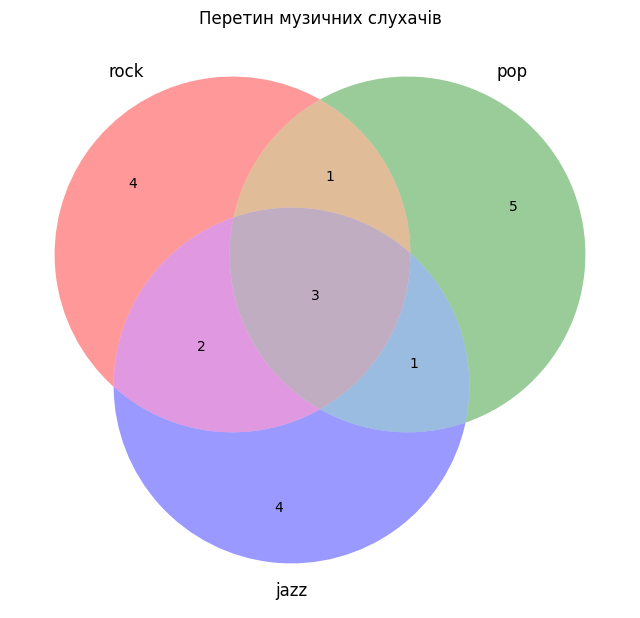

In [1]:
# Твоє рішення для Задачі 1
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

rock_fans = {101, 102, 103, 105, 107, 109, 110, 112, 115, 118}
pop_fans = {102, 104, 105, 106, 108, 110, 111, 113, 115, 117}
jazz_fans = {103, 105, 108, 110, 112, 114, 115, 116, 119, 120}

all_uniun = rock_fans | pop_fans | jazz_fans
print(f"Загальне охорлення {len(all_uniun)}")

entersection = rock_fans & pop_fans & jazz_fans
print(f"Слухали всі 3 жанри{len(entersection)}")

only_rock = rock_fans - (pop_fans | jazz_fans)
print(f"Тільки рок{len(only_rock)}")

rock_pop_only = (rock_fans & pop_fans) - jazz_fans
rock_jazz_only = (rock_fans & jazz_fans) - pop_fans
pop_jazz_only = (pop_fans & jazz_fans) - rock_fans
union_only = rock_pop_only | rock_jazz_only | pop_jazz_only

print(f'Слухають рівно 2 жанри {union_only}')

plt.figure(figsize=(8, 8))
venn3([rock_fans, pop_fans, jazz_fans], ('rock', 'pop', 'jazz'))
plt.title('Перетин музичних слухачів')
plt.show()


## Задача 2. Конфігуратор доступу до системи
**Умова**
Ви розробляєте модуль авторизації (RBAC — Role-Based Access Control) для корпоративного порталу. Доступ до різних секцій сайту визначається комбінацією п'яти параметрів користувача. Вам потрібно змоделювати цю логіку та перевірити всі можливі сценарії.

**Вхідні параметри користувача (булеві змінні):**
1. `is_employee` — чи є співробітником компанії
2. `is_verified` — чи пройшов верифікацію пошти
3. `is_premium` — чи має преміум-підписку
4. `is_admin` — чи є адміністратором
5. `is_banned` — чи заблокований акаунт

**Правила доступу до секцій:**
Система має 4 рівні доступу. Доступ надається (`True`), якщо виконується логічна умова:
* **Base (Базовий):** Користувач є співробітником **ТА** верифікований **ТА НЕ** заблокований.
* **Premium (Преміум):** (Користувач є співробітником **АБО** має преміум) **ТА** верифікований **ТА НЕ** заблокований.
* **Admin (Адмін-панель):** Користувач є адміністратором **ТА** верифікований **ТА НЕ** заблокований.
* **Secret (Секретні матеріали):** (Користувач є адміністратором **АБО** (є співробітником **ТА** має преміум)) **ТА** верифікований **ТА НЕ** заблокований.

Напишіть програму на Python, яка виконує наступні кроки:

1. Реалізуйте функцію `check_access` у комірці з кодом нижче. Функція повинна повертати словник вигляду `{'Base': ..., 'Premium': ..., 'Admin': ..., 'Secret': ...}`, де значення — це `True` або `False`.
2. Згенеруйте **Таблицю істинності** для всіх 32 можливих комбінацій параметрів ($2^5 = 32$). *Підказка: Використовуйте `itertools.product([True, False], repeat=5)` для генерації вхідних даних.*
3. Виведіть таблицю у читабельному форматі (див. приклад у коментарях до коду). Перші 5 стовпчиків це вхідні параметри користувача, а останні 4 це чи є доступ до відповідного рівня.
4. Проаналізуйте результати та дайте відповіді на питання (в програмі чи текстом):
   * У скількох випадках користувач має повний доступ (до всіх 4 секцій одночасно)?
   * Чи існує комбінація, де користувач має доступ до **Premium**, але **не має** доступу до **Base**? Якщо так, виведіть параметри цієї комбінації та поясніть, чому так сталося.


In [2]:
# Твоє рішення для Задачі 2
import itertools

# 1. Реалізація функції перевірки доступу
def check_access(is_employee, is_verified, is_premium, is_admin, is_banned):
    is_active = is_verified and not is_banned
    is_base = is_active and is_employee
    premium_access = (is_premium or is_employee) and is_active
    admin_access = is_admin and is_active
    secret_access = (is_admin or (is_employee and is_premium)) and is_active
    return {
        "Base": is_base,
        "Premium": premium_access,
        "Admin": admin_access,
        "Secret": secret_access
    }




# ПРИКЛАД БАЖАНОГО ВИВОДУ ТАБЛИЦІ (для кроку 3):
# Emp  Ver  Prem Adm  Ban  | Base Prem Adm  Secr
# -------------------------------------------------
# 1    1    1    1    1    | 0    0    0    0
# 1    1    1    1    0    | 1    1    1    1
# 1    1    1    0    1    | 0    0    0    0
# ... і далі всього 32 рядки


In [3]:
print("Emp  Ver Prem Adm Ban| Base Prem Adm  Secr")
print(46*"-")

whole_access_count = 0
premium_base_case = None

boolian_valius = [True, False]
for emp, ver, prem, adm, ban in itertools.product(boolian_valius, repeat=5):
  access = check_access(emp, ver, prem, adm, ban)
  row = f"{int(emp):<3} {int(ver):<3} {int(prem):<3} {int(adm):<3} {int(ban):<3} | "
  row += f"{int(access['Base']):<3} {int(access['Premium']):<3} {int(access['Admin']):<3} {int(access['Secret']):<3}"
  print(row)

  if access["Base"] and access["Premium"] and access["Admin"] and access["Secret"]:
    whole_access_count += 1

  if not access["Base"] and access["Premium"]:
    premium_base_case = (emp, ver, prem, adm, ban)
  print(46*"-")

if premium_base_case:
    e, v, p, a, b = premium_base_case
    print(f"Параметри: Співробітник={e}, Вериф={v}, Преміум={p}, Адмін={a}, Бан={b}")
    print("Пояснення: Користувач НЕ є співробітником (Base=False), але купив Преміум. ")



Emp  Ver Prem Adm Ban| Base Prem Adm  Secr
----------------------------------------------
1   1   1   1   1   | 0   0   0   0  
----------------------------------------------
1   1   1   1   0   | 1   1   1   1  
----------------------------------------------
1   1   1   0   1   | 0   0   0   0  
----------------------------------------------
1   1   1   0   0   | 1   1   0   1  
----------------------------------------------
1   1   0   1   1   | 0   0   0   0  
----------------------------------------------
1   1   0   1   0   | 1   1   1   1  
----------------------------------------------
1   1   0   0   1   | 0   0   0   0  
----------------------------------------------
1   1   0   0   0   | 1   1   0   0  
----------------------------------------------
1   0   1   1   1   | 0   0   0   0  
----------------------------------------------
1   0   1   1   0   | 0   0   0   0  
----------------------------------------------
1   0   1   0   1   | 0   0   0   0  
----------------------

## Задача 3. Формування "Команди мрії"
**Умова**
Ви — Tech Lead нового амбітного стартапу. Ваше перше завдання — сформувати ідеальну команду для розробки MVP (Minimum Viable Product). HR-відділ надав вам списки кандидатів, які успішно пройшли технічну співбесіду.

У пулі кандидатів є:
* Back-end розробники: 8 осіб
* Front-end розробники: 6 осіб
* UI/UX Дизайнери: 4 особи

Згідно з бюджетом та архітектурою проєкту, команда має складатися рівно з **5 осіб** і мати таку структуру:
1. **2** Back-end розробники.
2. **2** Front-end розробники.
3. **1** Дизайнер.

Оскільки всі кандидати у списках кваліфіковані, порядок їх вибору не має значення (команда "Олег і Анна" — це те саме, що "Анна і Олег").

Тобто, це задача на **сполучення** (combinations). Однак, оскільки ми формуємо одну цілісну команду з різних груп, нам знадобиться **правило множення**.

Напишіть програму на Python, яка використовує модуль `math` та виконує наступні кроки:

1. Обчисліть, скількома способами можна вибрати необхідну кількість Back-end розробників.
2. Обчисліть, скількома способами можна вибрати необхідну кількість Front-end розробників.
3. Обчисліть, скількома способами можна вибрати одного дизайнера.
4. Використовуючи комбінаторне правило множення, знайдіть **загальну кількість** можливих унікальних складів команди.
5. Виведіть проміжні результати та фінальну відповідь у зрозумілому форматі.


In [6]:
import math

# Вхідні дані
num_backend_candidates = 8
num_frontend_candidates = 6
num_designer_candidates = 4

# Необхідний склад команди
required_backend = 2
required_frontend = 2
required_designer = 1

# 1. Обчислити кількість способів вибрати Back-end розробників
ways_backend = math.comb(num_backend_candidates, required_backend)
print(f"Кількість способів вибрати {required_backend} Back-end розробників з {num_backend_candidates}: {ways_backend}")

# 2. Обчислити кількість способів вибрати Front-end розробників
ways_frontend = math.comb(num_frontend_candidates, required_frontend)
print(f"Кількість способів вибрати {required_frontend} Front-end розробників з {num_frontend_candidates}: {ways_frontend}")

# 3. Обчислити кількість способів вибрати одного дизайнера
ways_designer = math.comb(num_designer_candidates, required_designer)
print(f"Кількість способів вибрати {required_designer} дизайнера з {num_designer_candidates}: {ways_designer}")

# 4. Обчислити загальну кількість можливих унікальних складів команди
total_ways = ways_backend * ways_frontend * ways_designer
print(f"\nЗагальна кількість унікальних складів команди: {total_ways}")

Кількість способів вибрати 2 Back-end розробників з 8: 28
Кількість способів вибрати 2 Front-end розробників з 6: 15
Кількість способів вибрати 1 дизайнера з 4: 4

Загальна кількість унікальних складів команди: 1680


## Задача 4. Аналіз соціальної мережі компанії
**Умова**
У невеликій IT-компанії працює 6 людей. HR-відділ хоче проаналізувати комунікацію в корпоративному месенджері: хто з ким спілкується. Вам надали дані про зв'язки між співробітниками.

Співробітники та їхні контакти (неорієнтований граф):
* **Анна** спілкується з: Богдан, Віктор, Ганна
* **Богдан** спілкується з: Анна, Віктор, Дмитро
* **Віктор** спілкується з: Анна, Богдан, Ганна, Дмитро
* **Ганна** спілкується з: Анна, Віктор, Євген
* **Дмитро** спілкується з: Богдан, Віктор, Євген
* **Євген** спілкується з: Ганна, Дмитро

Напишіть програму на Python, яка виконує наступні кроки:

1. Побудуйте **три різні представлення** цього графа:
   * Матриця суміжності (як вкладені списки)
   * Список суміжності (як словник)
   * Список ребер (як список кортежів)
2. Обчисліть **степінь кожної вершини** (кількість зв'язків кожного співробітника). Визначте, хто найбільш комунікабельний, а хто — найменш.
3. **Перевірте теорему про суму степенів:** сума степенів усіх вершин дорівнює подвоєній кількості ребер. Виведіть суму всіх степенів, кількість ребер у графі та підтвердження, що рівність виконується.


In [5]:
employees = ["Анна", "Богдан", "Віктор", "Ганна", "Дмитро", "Євген"]

communications = {
    "Анна": ["Богдан", "Віктор", "Ганна"],
    "Богдан": ["Анна", "Віктор", "Дмитро"],
    "Віктор": ["Анна", "Богдан", "Ганна", "Дмитро"],
    "Ганна": ["Анна", "Віктор", "Євген"],
    "Дмитро": ["Богдан", "Віктор", "Євген"],
    "Євген": ["Ганна", "Дмитро"]
}

# 1. Побудова трьох різних представлень графа

# Створення словника для швидкого доступу до індексів співробітників
emp_to_index = {name: i for i, name in enumerate(employees)}

# Матриця суміжності
adj_matrix = [[0 for _ in range(len(employees))] for _ in range(len(employees))]
for emp, contacts in communications.items():
    emp_idx = emp_to_index[emp]
    for contact in contacts:
        contact_idx = emp_to_index[contact]
        adj_matrix[emp_idx][contact_idx] = 1

print("\nМатриця суміжності:")
# Додамо заголовок для зручності
header = "   " + " ".join([name[:1] for name in employees])
print(header)
print(" --" + "--" * len(employees))
for i, row in enumerate(adj_matrix):
    print(f"{employees[i][0]:<2}| {' '.join(map(str, row))}")


# Список суміжності (вже надано як communications)
adj_list = communications
print("\nСписок суміжності:")
for emp, contacts in adj_list.items():
    print(f"{emp}: {', '.join(contacts)}")

# Список ребер
edge_list = []
# Використовуємо set для уникнення дублікатів (оскільки граф неорієнтований)
# і для забезпечення унікальності ребер (A-B те саме, що B-A)
seen_edges = set()
for emp, contacts in communications.items():
    for contact in contacts:
        edge = tuple(sorted((emp, contact))) # Сортуємо для уникнення дублікатів
        if edge not in seen_edges:
            edge_list.append(edge)
            seen_edges.add(edge)

print("\nСписок ребер:")
for edge in edge_list:
    print(f"{edge[0]} - {edge[1]}")

# 2. Обчислення степеня кожної вершини

degrees = {}
for emp in employees:
    # Степень вершини в неорієнтованому графі - це кількість її сусідів
    degrees[emp] = len(communications[emp])

print("\nСтепені вершин:")
max_degree = -1
min_degree = float('inf')
most_communicative = []
least_communicative = []

for emp, degree in degrees.items():
    print(f"{emp}: {degree}")
    if degree > max_degree:
        max_degree = degree
        most_communicative = [emp]
    elif degree == max_degree:
        most_communicative.append(emp)

    if degree < min_degree:
        min_degree = degree
        least_communicative = [emp]
    elif degree == min_degree:
        least_communicative.append(emp)

print(f"Найбільш комунікабельні: {', '.join(most_communicative)} (степінь {max_degree})")
print(f"Найменш комунікабельні: {', '.join(least_communicative)} (степінь {min_degree})")

# 3. Перевірка теореми про суму степенів

sum_of_degrees = sum(degrees.values())
num_edges = len(edge_list)

print(f"\nСума всіх степенів: {sum_of_degrees}")
print(f"Кількість ребер у графі: {num_edges}")
print(f"Перевірка теореми (Сума степенів == 2 * Кількість ребер): {sum_of_degrees} == {2 * num_edges} -> {sum_of_degrees == 2 * num_edges}")


Матриця суміжності:
   А Б В Г Д Є
 --------------
А | 0 1 1 1 0 0
Б | 1 0 1 0 1 0
В | 1 1 0 1 1 0
Г | 1 0 1 0 0 1
Д | 0 1 1 0 0 1
Є | 0 0 0 1 1 0

Список суміжності:
Анна: Богдан, Віктор, Ганна
Богдан: Анна, Віктор, Дмитро
Віктор: Анна, Богдан, Ганна, Дмитро
Ганна: Анна, Віктор, Євген
Дмитро: Богдан, Віктор, Євген
Євген: Ганна, Дмитро

Список ребер:
Анна - Богдан
Анна - Віктор
Анна - Ганна
Богдан - Віктор
Богдан - Дмитро
Віктор - Ганна
Віктор - Дмитро
Євген - Ганна
Євген - Дмитро

Степені вершин:
Анна: 3
Богдан: 3
Віктор: 4
Ганна: 3
Дмитро: 3
Євген: 2
Найбільш комунікабельні: Віктор (степінь 4)
Найменш комунікабельні: Євген (степінь 2)

Сума всіх степенів: 18
Кількість ребер у графі: 9
Перевірка теореми (Сума степенів == 2 * Кількість ребер): 18 == 18 -> True
